# MVPA Distinctiveness Analysis
Port of 02_strippeddown.ipynb to sym_pt project.

**Changes from long_pt version:**
1. Paths point to sym_pt processed directory
2. Subject info from unified long-format CSV via sym_pt_params
3. Brain mask from ses-01 applied before thresholding (new)

**Everything else matches long_pt:** same COPE_MAP, same 6mm sphere, same z>2.3 threshold, same distinctiveness metric.

In [26]:
# CELL 1: Setup & Configuration
import os, sys
import numpy as np
import nibabel as nib
import pandas as pd
import pickle
from pathlib import Path
from scipy.ndimage import label, center_of_mass
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, is_patient,
                           get_sessions, get_sub_info, _load_csv)

BASE_DIR = Path(processed_dir)
OUTPUT_DIR = BASE_DIR / 'analyses' / 'mvpa_distinctiveness'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Same COPE_MAP as long_pt — used for BOTH ROI definition AND RSA
# Differential contrasts for ROI definition (cell 3)
COPE_MAP = {'face': 1, 'house': 2, 'object': 3, 'word': 12}

# Raw category betas for RSA (cell 4)
RSA_COPE_MAP = {'face': 15, 'house': 16, 'object': 17, 'word': 18}

# Temporary validation - match original long_pt
VALIDATION_COPE_MAP = {'face': 1, 'house': 2, 'object': 3, 'word': 12}

BILATERAL_CATEGORIES = ['object', 'house']
UNILATERAL_CATEGORIES = ['face', 'word']

print(f'Base: {BASE_DIR}')
print(f'COPE_MAP: {COPE_MAP}')
print('Setup complete.')

# RSA cope map options
RSA_COPE_MAP = {'face': 15, 'house': 16, 'object': 17, 'word': 18}  # raw category betas
CAT_VS_SCRAMBLE_MAP = {'face': 1, 'house': 2, 'object': 3, 'word': 12}  # differential contrasts

# Choose which RSA method to use
RSA_METHOD = 'raw'  # 'raw' or 'cat_vs_scramble'
ACTIVE_RSA_MAP = RSA_COPE_MAP if RSA_METHOD == 'raw' else CAT_VS_SCRAMBLE_MAP

# Pre-surgical sessions to exclude from longitudinal analyses
PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'],
    'sub-045': ['01'],
    'sub-047': ['01'],
    'sub-049': ['01'],
    'sub-070': ['01'],
    'sub-073': ['01'],
    'sub-081': ['01'],
    'sub-086': ['01'],
}

# Age-matched exclusions
AGE_MATCH_DROP = ['sub-025', 'sub-027', 'sub-045', 'sub-072']

# Subjects to skip entirely
SUBJECTS_TO_SKIP = ['OTC108']

# Preferred hemisphere per category (Ayzenberg 2023)
PREFERRED_HEMI = {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}

print(f'RSA method: {RSA_METHOD}')
print(f'Active RSA map: {ACTIVE_RSA_MAP}')
print(f'Pre-surgical exclusions: {len(PRE_SURGERY_SESSIONS)} subjects')


Base: /user_data/csimmon2/sym_pt
COPE_MAP: {'face': 1, 'house': 2, 'object': 3, 'word': 12}
Setup complete.
RSA method: raw
Active RSA map: {'face': 15, 'house': 16, 'object': 17, 'word': 18}
Pre-surgical exclusions: 8 subjects


In [27]:
# CELL 2: Load Subjects
df = _load_csv()

def load_subjects(patient_only=None):
    """Load subjects from unified CSV. patient_only: True/False/None(all)"""
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sessions = get_sessions(sub_clean)
        if not sessions:
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)

        if patient_only is True and not pt:
            continue
        if patient_only is False and pt:
            continue

        # Check directory exists
        if not (BASE_DIR / f'sub-{sub_clean}').exists():
            continue

        intact = info.get('intact_hemi', '')
        if pt:
            hemi = 'l' if intact == 'left' else 'r'
        else:
            hemi = 'r'  # default for controls; left done separately

        subjects[f'sub-{sub_clean}'] = {
            'code': f"{info.get('group','')}{sub_clean}",
            'sessions': [f'{s:02d}' for s in sessions],
            'hemi': hemi,
            'group': info.get('group', 'unknown'),
            'patient_status': 'patient' if pt else 'control',
            'intact_hemi': intact
        }
    return subjects

ALL_PATIENTS = load_subjects(patient_only=True)
ALL_CONTROLS = load_subjects(patient_only=False)
ANALYSIS_SUBJECTS = {**ALL_PATIENTS, **ALL_CONTROLS}

print(f'Loaded {len(ANALYSIS_SUBJECTS)} subjects')
print(f'  Patients: {len(ALL_PATIENTS)}, Controls: {len(ALL_CONTROLS)}')

# ============================================================================
# CELL 2 ADDITION: Add helper function after load_subjects
# ============================================================================

def get_post_surgery_sessions(subject_id, all_sessions):
    """Filter to only post-surgical sessions for a subject."""
    if subject_id in PRE_SURGERY_SESSIONS:
        pre_sessions = PRE_SURGERY_SESSIONS[subject_id]
        return [s for s in all_sessions if s not in pre_sessions]
    return all_sessions

def get_longitudinal_sessions(subject_id, all_sessions):
    """Get valid session pairs for longitudinal analysis (post-surgery only)."""
    post_sessions = get_post_surgery_sessions(subject_id, all_sessions)
    if len(post_sessions) >= 2:
        return post_sessions
    return []

print(f"\nLongitudinal eligibility:")
for sid, info in ANALYSIS_SUBJECTS.items():
    long_ses = get_longitudinal_sessions(sid, info['sessions'])
    if info['patient_status'] == 'patient' and len(long_ses) < 2:
        print(f"  {info['code']}: NO valid longitudinal data (post-surgery sessions: {get_post_surgery_sessions(sid, info['sessions'])})")


Loaded 50 subjects
  Patients: 26, Controls: 24

Longitudinal eligibility:
  nonOTC047: NO valid longitudinal data (post-surgery sessions: ['02'])
  nonOTC049: NO valid longitudinal data (post-surgery sessions: ['02'])
  OTC066: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC069: NO valid longitudinal data (post-surgery sessions: ['01'])
  nonOTC070: NO valid longitudinal data (post-surgery sessions: ['02'])
  nonOTC073: NO valid longitudinal data (post-surgery sessions: ['02'])
  OTC074: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC075: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC076: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC077: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC078: NO valid longitudinal data (post-surgery sessions: ['01'])
  nonOTC081: NO valid longitudinal data (post-surgery sessions: ['02'])
  nonOTC086: NO valid longitudinal data (post-surgery sessions: ['02'])
  OTC089: 

In [6]:
# CELL 3: ROI Extraction

def extract_rois(subject_id, subjects_dict, threshold_z=2.3):
    """Extract functional cluster ROIs across all sessions."""
    if subject_id not in subjects_dict:
        return {}

    info = subjects_dict[subject_id]
    code = info['code']
    hemi = info['hemi']
    sessions = info['sessions']
    first_session = sessions[0]

    print(f"{code} - Extracting ROIs [{info['group']} {info['patient_status']}, hemi={hemi}]")

    # Brain mask from FIRST session (all data registered to this space)
    brain_mask_file = BASE_DIR / subject_id / f'ses-{first_session}' / 'anat' / 'T1w_brain_mask.nii.gz'
    brain_mask = nib.load(str(brain_mask_file)).get_fdata() > 0 if brain_mask_file.exists() else None

    all_results = {}

    for category, cope_num in COPE_MAP.items():
        all_results[category] = {}

        # Search mask from first session
        mask_file = None
        for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
            p = BASE_DIR / subject_id / f'ses-{first_session}' / subdir / f'{hemi}_{category}_searchmask.nii.gz'
            if p.exists():
                mask_file = p
                break

        if mask_file is None:
            print(f"  {category}: mask not found")
            continue

        mask = nib.load(str(mask_file)).get_fdata() > 0
        affine = nib.load(str(mask_file)).affine

        for session in sessions:
            feat_dir = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'

            zstat_name = 'zstat1.nii.gz' if session == first_session else f'zstat1_ses{first_session}.nii.gz'
            cope_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / zstat_name

            if not cope_file.exists():
                continue

            zstat = nib.load(str(cope_file)).get_fdata()

            # Apply brain mask from first session
            if brain_mask is not None:
                zstat[~brain_mask] = 0

            suprathresh = (zstat > threshold_z) & mask

            if suprathresh.sum() < 50:
                continue

            labeled, n_clusters = label(suprathresh)
            if n_clusters == 0:
                continue

            cluster_sizes = [(labeled == i).sum() for i in range(1, n_clusters + 1)]
            largest_idx = np.argmax(cluster_sizes) + 1
            roi_mask = (labeled == largest_idx)

            peak_idx = np.unravel_index(np.argmax(zstat * roi_mask), zstat.shape)
            peak_z = zstat[peak_idx]
            centroid = nib.affines.apply_affine(affine, center_of_mass(roi_mask))

            all_results[category][session] = {
                'n_voxels': cluster_sizes[largest_idx - 1],
                'peak_z': peak_z,
                'centroid': centroid,
                'roi_mask': roi_mask
            }

    return all_results


print('\nEXTRACTING FUNCTIONAL ROIs')
print('=' * 70)

# Extract patient ROIs
functional_rois = {}
for subject_id in ALL_PATIENTS.keys():
    try:
        functional_rois[subject_id] = extract_rois(subject_id, ANALYSIS_SUBJECTS)
    except Exception as e:
        print(f"  {subject_id} failed: {e}")
        functional_rois[subject_id] = {}

# Extract control ROIs - RIGHT hemisphere
for subject_id in ALL_CONTROLS.keys():
    try:
        functional_rois[subject_id] = extract_rois(subject_id, ANALYSIS_SUBJECTS)
    except Exception as e:
        print(f"  {subject_id} failed: {e}")
        functional_rois[subject_id] = {}

print(f'\nExtracted {len(functional_rois)} subjects')

# Extract control ROIs - LEFT hemisphere
print('\nEXTRACTING CONTROLS LEFT HEMISPHERE')
print('=' * 70)

controls_left_functional = {}
for subject_id in ALL_CONTROLS.keys():
    temp_subjects = {subject_id: {**ANALYSIS_SUBJECTS[subject_id], 'hemi': 'l'}}
    try:
        controls_left_functional[subject_id] = extract_rois(subject_id, temp_subjects)
    except Exception as e:
        print(f"  {subject_id} failed: {e}")
        controls_left_functional[subject_id] = {}

print(f'\nExtracted left hemisphere for {len(controls_left_functional)} controls')


EXTRACTING FUNCTIONAL ROIs
OTC004 - Extracting ROIs [OTC patient, hemi=l]
nonOTC007 - Extracting ROIs [nonOTC patient, hemi=r]
OTC008 - Extracting ROIs [OTC patient, hemi=l]
OTC010 - Extracting ROIs [OTC patient, hemi=r]
OTC017 - Extracting ROIs [OTC patient, hemi=r]
OTC021 - Extracting ROIs [OTC patient, hemi=r]
nonOTC045 - Extracting ROIs [nonOTC patient, hemi=r]
nonOTC047 - Extracting ROIs [nonOTC patient, hemi=l]
nonOTC049 - Extracting ROIs [nonOTC patient, hemi=l]
OTC066 - Extracting ROIs [OTC patient, hemi=r]
OTC069 - Extracting ROIs [OTC patient, hemi=r]
nonOTC070 - Extracting ROIs [nonOTC patient, hemi=r]
nonOTC072 - Extracting ROIs [nonOTC patient, hemi=l]
nonOTC073 - Extracting ROIs [nonOTC patient, hemi=l]
OTC074 - Extracting ROIs [OTC patient, hemi=l]
OTC075 - Extracting ROIs [OTC patient, hemi=l]
OTC076 - Extracting ROIs [OTC patient, hemi=l]
OTC077 - Extracting ROIs [OTC patient, hemi=l]
OTC078 - Extracting ROIs [OTC patient, hemi=r]
OTC079 - Extracting ROIs [OTC patient

In [ ]:
# CELL 4: RSA Analysis

def create_sphere(peak_coord, affine, brain_shape, radius=6):
    """Create 6mm sphere around peak."""
    grid_coords = np.array(np.meshgrid(
        np.arange(brain_shape[0]),
        np.arange(brain_shape[1]),
        np.arange(brain_shape[2]),
        indexing='ij'
    )).reshape(3, -1).T

    grid_world = nib.affines.apply_affine(affine, grid_coords)
    distances = np.linalg.norm(grid_world - peak_coord, axis=1)

    mask_3d = np.zeros(brain_shape, dtype=bool)
    within = grid_coords[distances <= radius]
    for coord in within:
        mask_3d[coord[0], coord[1], coord[2]] = True
    return mask_3d


def extract_betas(subject_id, session, sphere_mask, category_copes):
    """Extract beta patterns from sphere."""
    info = ANALYSIS_SUBJECTS[subject_id]
    first_session = info['sessions'][0]

    feat_dir = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'

    beta_patterns = []
    valid_categories = []

    for category, cope_num in category_copes.items():
        cope_name = 'cope1.nii.gz' if session == first_session else f'cope1_ses{first_session}.nii.gz'
        cope_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / cope_name

        if not cope_file.exists():
            continue

        cope_data = nib.load(str(cope_file)).get_fdata()
        roi_betas = cope_data[sphere_mask]
        roi_betas = roi_betas[np.isfinite(roi_betas)]

        if len(roi_betas) > 0:
            beta_patterns.append(roi_betas)
            valid_categories.append(category)

    if len(beta_patterns) == 0:
        return None, None

    min_voxels = min(len(b) for b in beta_patterns)
    beta_patterns = [b[:min_voxels] for b in beta_patterns]
    beta_matrix = np.column_stack(beta_patterns)
    return beta_matrix, valid_categories


def compute_rdm(beta_matrix, fisher_transform=True):
    """Compute RDM from beta patterns."""
    correlation_matrix = np.corrcoef(beta_matrix.T)
    rdm = 1 - correlation_matrix
    if fisher_transform:
        corr_fisher = np.arctanh(np.clip(correlation_matrix, -0.999, 0.999))
        return rdm, corr_fisher
    return rdm, correlation_matrix


def extract_rdms(functional_results, analysis_subjects):
    """Extract all RDMs from 6mm spheres."""
    all_rdms = {}

    for subject_id in analysis_subjects.keys():
        if subject_id not in functional_results:
            continue

        info = analysis_subjects[subject_id]
        code = info['code']
        sessions = info['sessions']
        first_session = sessions[0]

        ref_file = None
        for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
            p = BASE_DIR / subject_id / f'ses-{first_session}' / subdir / f"{info['hemi']}_face_searchmask.nii.gz"
            if p.exists():
                ref_file = p
                break
        if ref_file is None:
            continue

        ref_img = nib.load(str(ref_file))
        affine = ref_img.affine
        brain_shape = ref_img.shape

        print(f"{code}: RSA Analysis")
        all_rdms[subject_id] = {}

        for roi_name in COPE_MAP.keys():
            if roi_name not in functional_results[subject_id]:
                continue

            all_rdms[subject_id][roi_name] = {
                'rdms': {}, 'correlation_matrices': {}, 'beta_patterns': {},
                'valid_categories': None, 'session_peaks': {}, 'session_n_voxels': {}
            }

            for session in sessions:
                if session not in functional_results[subject_id][roi_name]:
                    continue

                peak = functional_results[subject_id][roi_name][session]['centroid']
                sphere_mask = create_sphere(peak, affine, brain_shape, radius=6)
                n_voxels = sphere_mask.sum()

                all_rdms[subject_id][roi_name]['session_peaks'][session] = peak
                all_rdms[subject_id][roi_name]['session_n_voxels'][session] = n_voxels

                beta_matrix, valid_cats = extract_betas(subject_id, session, sphere_mask, RSA_COPE_MAP)
                #beta_matrix, valid_cats = extract_betas(subject_id, session, sphere_mask, COPE_MAP)


                if beta_matrix is None:
                    continue

                rdm, corr_fisher = compute_rdm(beta_matrix, fisher_transform=True)

                all_rdms[subject_id][roi_name]['rdms'][session] = rdm
                all_rdms[subject_id][roi_name]['correlation_matrices'][session] = corr_fisher
                all_rdms[subject_id][roi_name]['beta_patterns'][session] = beta_matrix
                all_rdms[subject_id][roi_name]['valid_categories'] = valid_cats

    return all_rdms


def compute_liu_metrics(all_rdms, analysis_subjects):
    """Compute Liu's distinctiveness."""
    distinctiveness_results = {}
    roi_preferred = {'face': 'face', 'word': 'word', 'object': 'object', 'house': 'house'}

    for subject_id, categories in all_rdms.items():
        if subject_id not in analysis_subjects:
            continue

        distinctiveness_results[subject_id] = {}

        for roi_name, roi_data in categories.items():
            if not roi_data['correlation_matrices']:
                continue

            valid_cats = roi_data['valid_categories']
            if valid_cats is None or len(valid_cats) < 4:
                continue

            preferred_cat = roi_preferred[roi_name]
            if preferred_cat not in valid_cats:
                continue

            pref_idx = valid_cats.index(preferred_cat)
            nonpref_indices = [i for i, cat in enumerate(valid_cats) if cat != preferred_cat]

            distinctiveness_results[subject_id][roi_name] = {}

            for session, corr_matrix in roi_data['correlation_matrices'].items():
                pref_vs_nonpref = corr_matrix[pref_idx, nonpref_indices]
                mean_corr = np.mean(pref_vs_nonpref)

                distinctiveness_results[subject_id][roi_name][session] = {
                    'liu_distinctiveness': mean_corr,
                    'individual_correlations': pref_vs_nonpref
                }

    return distinctiveness_results


print('\nEXTRACTING RSA DATA')
print('=' * 70)

all_rdms = extract_rdms(functional_rois, ANALYSIS_SUBJECTS)
liu_distinctiveness = compute_liu_metrics(all_rdms, ANALYSIS_SUBJECTS)

print('\nCONTROLS LEFT HEMISPHERE RSA')
print('=' * 70)
controls_left_rdms = extract_rdms(controls_left_functional, ALL_CONTROLS)
controls_left_distinctiveness = compute_liu_metrics(controls_left_rdms, ALL_CONTROLS)

print('\nRSA analysis complete!')

# ============================================================================
# CELL 4 UPDATE: Change extract_betas call in extract_rdms
# Replace the existing extract_rdms call at bottom of cell 4
# ============================================================================

# In extract_rdms function, change this line:
#   beta_matrix, valid_cats = extract_betas(subject_id, session, sphere_mask, COPE_MAP)
# To:
#   beta_matrix, valid_cats = extract_betas(subject_id, session, sphere_mask, ACTIVE_RSA_MAP)

# Then at the bottom of cell 4:
print(f'\nRSA METHOD: {RSA_METHOD}')
print(f'Using cope map: {ACTIVE_RSA_MAP}')
print('\nEXTRACTING RSA DATA')
print('=' * 70)

all_rdms = extract_rdms(functional_rois, ANALYSIS_SUBJECTS)
liu_distinctiveness = compute_liu_metrics(all_rdms, ANALYSIS_SUBJECTS)

print('\nCONTROLS LEFT HEMISPHERE RSA')
print('=' * 70)
controls_left_rdms = extract_rdms(controls_left_functional, ALL_CONTROLS)
controls_left_distinctiveness = compute_liu_metrics(controls_left_rdms, ALL_CONTROLS)

print('\nRSA analysis complete!')


EXTRACTING RSA DATA
OTC004: RSA Analysis
nonOTC007: RSA Analysis
OTC008: RSA Analysis
OTC010: RSA Analysis
OTC017: RSA Analysis
OTC021: RSA Analysis
nonOTC045: RSA Analysis
nonOTC047: RSA Analysis
nonOTC049: RSA Analysis
OTC066: RSA Analysis
OTC069: RSA Analysis
nonOTC070: RSA Analysis
nonOTC072: RSA Analysis
nonOTC073: RSA Analysis
OTC074: RSA Analysis
OTC075: RSA Analysis
OTC076: RSA Analysis
OTC077: RSA Analysis
OTC078: RSA Analysis
OTC079: RSA Analysis
nonOTC081: RSA Analysis
nonOTC086: RSA Analysis
OTC089: RSA Analysis
OTC090: RSA Analysis
OTC091: RSA Analysis
OTC092: RSA Analysis
control018: RSA Analysis
control022: RSA Analysis
control025: RSA Analysis
control027: RSA Analysis
control038: RSA Analysis
control052: RSA Analysis
control057: RSA Analysis
control058: RSA Analysis
control059: RSA Analysis
control062: RSA Analysis
control064: RSA Analysis
control067: RSA Analysis
control068: RSA Analysis
control071: RSA Analysis
control083: RSA Analysis
control084: RSA Analysis
contro

In [ ]:
# CELL 5: Spatial Analysis

SUBJECTS_TO_SKIP = ['OTC108']

def get_bootstrapped_error_radius(pair_peaks, n_bootstraps=1000):
    """Calculate bootstrapped measurement error radius."""
    if not pair_peaks or len(pair_peaks) < 2:
        return 1.0
    data = np.array([p['coord'][:2] for p in pair_peaks])
    def stat_func(coords):
        if len(np.unique(coords[:, 0])) < 2 or len(np.unique(coords[:, 1])) < 2:
            return 0.0
        return np.sqrt(np.std(coords[:, 0])**2 + np.std(coords[:, 1])**2)
    bootstrapped = [stat_func(data[np.random.choice(len(data), len(data), replace=True)])
                    for _ in range(n_bootstraps)]
    result = np.mean(bootstrapped)
    return result if not np.isnan(result) and result > 0 else stat_func(data)


def calc_error_radii(functional_results, analysis_subjects):
    radii = {}
    for subject_id in analysis_subjects.keys():
        if subject_id not in functional_results:
            continue
        radii[subject_id] = {}
        for category, sessions_data in functional_results[subject_id].items():
            if len(sessions_data) < 2:
                radii[subject_id][category] = 1.0
                continue
            pair_peaks = [{'coord': data['centroid'], 'session': session}
                         for session, data in sessions_data.items()]
            radii[subject_id][category] = get_bootstrapped_error_radius(pair_peaks)
    return radii


def calc_drift(functional_results, radii, analysis_subjects):
    drift_results = {}
    for subject_id, categories in functional_results.items():
        if subject_id not in analysis_subjects:
            continue
        drift_results[subject_id] = {}
        for category, sessions_data in categories.items():
            if len(sessions_data) < 2:
                continue
            sessions = sorted(sessions_data.keys())
            baseline_session = sessions[0]
            baseline_centroid = sessions_data[baseline_session]['centroid']
            error_radius = radii[subject_id].get(category, 1.0)
            drift_results[subject_id][category] = {
                'baseline_session': baseline_session,
                'baseline_centroid': baseline_centroid,
                'error_radius': error_radius,
                'from_baseline_drift': []
            }
            for session in sessions[1:]:
                current_centroid = sessions_data[session]['centroid']
                drift_distance = np.linalg.norm(current_centroid - baseline_centroid)
                drift_results[subject_id][category]['from_baseline_drift'].append({
                    'session': session,
                    'distance_mm': drift_distance,
                    'relative_to_error': drift_distance / error_radius
                })
    return drift_results


def calc_hemisphere_effects(drift_data, distinctiveness_data, analysis_subjects,
                           controls_left_drift=None, controls_left_distinct=None):
    """Calculate hemisphere-specific effects including controls both hemispheres."""
    table_data = []

    for subject_id in analysis_subjects.keys():
        info = analysis_subjects[subject_id]
        code = info['code']

        # Skip subjects with known issues
        if code in SUBJECTS_TO_SKIP:
            continue

        if info['patient_status'] == 'control' and controls_left_drift:
            for hemi_suffix, hemi_label, drift_source, distinct_source in [
                ('_R', 'r', drift_data.get(subject_id, {}), distinctiveness_data.get(subject_id, {})),
                ('_L', 'l', controls_left_drift.get(subject_id, {}),
                 controls_left_distinct.get(subject_id, {}) if controls_left_distinct else {})
            ]:
                spatial_data = {}
                repr_data = {}
                for category, drift_info in drift_source.items():
                    if drift_info.get('from_baseline_drift'):
                        spatial_data[category] = np.mean([d['distance_mm'] for d in drift_info['from_baseline_drift']])
                for category, sessions in distinct_source.items():
                    session_keys = sorted(sessions.keys())
                    if len(session_keys) >= 2:
                        baseline = sessions[session_keys[0]]['liu_distinctiveness']
                        final = sessions[session_keys[-1]]['liu_distinctiveness']
                        repr_data[category] = abs(final - baseline)
                for category in COPE_MAP.keys():
                    if category in spatial_data:
                        table_data.append({
                            'Subject': code + hemi_suffix,
                            'Group': info['group'],
                            'Status': info['patient_status'],
                            'Hemisphere': hemi_label,
                            'Category': category.title(),
                            'Category_Type': 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral',
                            'Spatial_Drift_mm': round(spatial_data[category], 2),
                            'Representational_Change': round(repr_data.get(category, 0), 3),
                            'Sessions': len(analysis_subjects[subject_id]['sessions'])
                        })
        else:
            spatial_data = {}
            repr_data = {}
            hemi_label = info['hemi']
            if subject_id in drift_data:
                for category, drift_info in drift_data[subject_id].items():
                    if drift_info.get('from_baseline_drift'):
                        spatial_data[category] = np.mean([d['distance_mm'] for d in drift_info['from_baseline_drift']])
            if subject_id in distinctiveness_data:
                for category, sessions in distinctiveness_data[subject_id].items():
                    session_keys = sorted(sessions.keys())
                    if len(session_keys) >= 2:
                        baseline = sessions[session_keys[0]]['liu_distinctiveness']
                        final = sessions[session_keys[-1]]['liu_distinctiveness']
                        repr_data[category] = abs(final - baseline)
            for category in COPE_MAP.keys():
                if category in spatial_data:
                    table_data.append({
                        'Subject': code,
                        'Group': info['group'],
                        'Status': info['patient_status'],
                        'Hemisphere': hemi_label,
                        'Category': category.title(),
                        'Category_Type': 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral',
                        'Spatial_Drift_mm': round(spatial_data[category], 2),
                        'Representational_Change': round(repr_data.get(category, 0), 3),
                        'Sessions': len(analysis_subjects[subject_id]['sessions'])
                    })

    return pd.DataFrame(table_data)


print('CALCULATING SPATIAL METRICS')
print('=' * 70)

error_radii = calc_error_radii(functional_rois, ANALYSIS_SUBJECTS)
drift_data = calc_drift(functional_rois, error_radii, ANALYSIS_SUBJECTS)

error_radii_left = calc_error_radii(controls_left_functional, ALL_CONTROLS)
controls_left_drift = calc_drift(controls_left_functional, error_radii_left, ALL_CONTROLS)

results_table = calc_hemisphere_effects(drift_data, liu_distinctiveness, ANALYSIS_SUBJECTS,
                                       controls_left_drift, controls_left_distinctiveness)

print(f'\nAnalysis complete: {len(results_table)} data points')
print(f'Skipped subjects: {SUBJECTS_TO_SKIP}')

# ============================================================================
# CELL 5 UPDATE: calc_hemisphere_effects with signed changes
# Replace the repr_data calculation section in calc_hemisphere_effects
# ============================================================================

def calc_hemisphere_effects(drift_data, distinctiveness_data, analysis_subjects,
                           controls_left_drift=None, controls_left_distinct=None):
    """Calculate hemisphere-specific effects with signed and absolute changes."""
    table_data = []

    for subject_id in analysis_subjects.keys():
        info = analysis_subjects[subject_id]
        code = info['code']

        if code in SUBJECTS_TO_SKIP:
            continue

        if info['patient_status'] == 'control' and controls_left_drift:
            for hemi_suffix, hemi_label, drift_source, distinct_source in [
                ('_R', 'r', drift_data.get(subject_id, {}), distinctiveness_data.get(subject_id, {})),
                ('_L', 'l', controls_left_drift.get(subject_id, {}),
                 controls_left_distinct.get(subject_id, {}) if controls_left_distinct else {})
            ]:
                spatial_data = {}
                repr_data = {}
                for category, drift_info in drift_source.items():
                    if drift_info.get('from_baseline_drift'):
                        spatial_data[category] = np.mean([d['distance_mm'] for d in drift_info['from_baseline_drift']])
                for category, sessions in distinct_source.items():
                    session_keys = sorted(sessions.keys())
                    if len(session_keys) >= 2:
                        baseline = sessions[session_keys[0]]['liu_distinctiveness']
                        final = sessions[session_keys[-1]]['liu_distinctiveness']
                        repr_data[category] = {
                            'abs_change': abs(final - baseline),
                            'signed_change': final - baseline,
                            'baseline': baseline,
                            'final': final
                        }
                for category in COPE_MAP.keys():
                    if category in spatial_data:
                        rd = repr_data.get(category, {'abs_change': 0, 'signed_change': 0, 'baseline': 0, 'final': 0})
                        table_data.append({
                            'Subject': code + hemi_suffix,
                            'Group': info['group'],
                            'Status': info['patient_status'],
                            'Hemisphere': hemi_label,
                            'Category': category.title(),
                            'Category_Type': 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral',
                            'Spatial_Drift_mm': round(spatial_data[category], 2),
                            'Abs_Change': round(rd['abs_change'], 3),
                            'Signed_Change': round(rd['signed_change'], 3),
                            'Baseline_Distinct': round(rd['baseline'], 3),
                            'Final_Distinct': round(rd['final'], 3),
                            'Sessions': len(analysis_subjects[subject_id]['sessions'])
                        })
        else:
            spatial_data = {}
            repr_data = {}
            hemi_label = info['hemi']

            # Get post-surgery sessions for longitudinal
            post_sessions = get_post_surgery_sessions(subject_id, info['sessions'])

            if subject_id in drift_data:
                for category, drift_info in drift_data[subject_id].items():
                    if drift_info.get('from_baseline_drift'):
                        # Filter to post-surgery drifts
                        valid_drifts = [d for d in drift_info['from_baseline_drift']
                                       if d['session'] in post_sessions]
                        if valid_drifts:
                            spatial_data[category] = np.mean([d['distance_mm'] for d in valid_drifts])

            if subject_id in distinctiveness_data:
                for category, sessions in distinctiveness_data[subject_id].items():
                    # Use only post-surgery sessions
                    session_keys = sorted([s for s in sessions.keys() if s in post_sessions])
                    if len(session_keys) >= 2:
                        baseline = sessions[session_keys[0]]['liu_distinctiveness']
                        final = sessions[session_keys[-1]]['liu_distinctiveness']
                        repr_data[category] = {
                            'abs_change': abs(final - baseline),
                            'signed_change': final - baseline,
                            'baseline': baseline,
                            'final': final
                        }

            for category in COPE_MAP.keys():
                if category in spatial_data or category in repr_data:
                    rd = repr_data.get(category, {'abs_change': 0, 'signed_change': 0, 'baseline': 0, 'final': 0})
                    table_data.append({
                        'Subject': code,
                        'Group': info['group'],
                        'Status': info['patient_status'],
                        'Hemisphere': hemi_label,
                        'Category': category.title(),
                        'Category_Type': 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral',
                        'Spatial_Drift_mm': round(spatial_data.get(category, 0), 2),
                        'Abs_Change': round(rd['abs_change'], 3),
                        'Signed_Change': round(rd['signed_change'], 3),
                        'Baseline_Distinct': round(rd['baseline'], 3),
                        'Final_Distinct': round(rd['final'], 3),
                        'Sessions': len(post_sessions)
                    })

    return pd.DataFrame(table_data)

CALCULATING SPATIAL METRICS



Analysis complete: 125 data points
Skipped subjects: ['OTC108']


In [ ]:
# CELL 6: Main Group Analysis

# Preferred hemisphere per category (Ayzenberg 2023)
PREFERRED_HEMI = {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}

def analyze_groups(results_table):
    print('THREE-GROUP COMPARISON: OTC vs nonOTC vs Controls')
    print('=' * 70)

    clean_data = results_table[results_table['Category_Type'] != 'Summary'].copy()

    # ── Controls: preferred hemisphere per category ──
    control_data = clean_data[clean_data['Status'] == 'control'].copy()
    control_data['Subject_Base'] = control_data['Subject'].str.replace('_L|_R', '', regex=True)

    # Keep only preferred hemisphere rows (both hemispheres kept for bilateral)
    preferred_rows = []
    for _, row in control_data.iterrows():
        pref = PREFERRED_HEMI[row['Category']]
        if pref == 'both' or row['Hemisphere'] == pref:
            preferred_rows.append(row)
    control_preferred = pd.DataFrame(preferred_rows)

    # Average per subject-category (collapses L+R for bilateral categories)
    controls = control_preferred.groupby(
        ['Subject_Base', 'Category', 'Category_Type']
    ).agg({
        'Spatial_Drift_mm': 'mean',
        'Representational_Change': 'mean'
    }).reset_index()

    # ── Patients ──
    patient_data = clean_data[clean_data['Status'] == 'patient']
    otc = patient_data[patient_data['Group'] == 'OTC']
    nonotc = patient_data[patient_data['Group'] == 'nonOTC']

    # ── Print Results ──
    print(f"\nHemisphere selection: {PREFERRED_HEMI}")
    print(f"Control subjects: {control_preferred['Subject_Base'].nunique()}")
    print(f"OTC patients: {otc['Subject'].nunique()}")
    print(f"nonOTC patients: {nonotc['Subject'].nunique()}")

    print(f"\nREPRESENTATIONAL CHANGE (Liu distinctiveness):")
    print(f"{'Group':<15} {'N':<5} {'Bilateral':<14} {'Unilateral':<14} {'Difference':<12}")
    print('-' * 60)

    for name, data in [('OTC', otc), ('nonOTC', nonotc), ('Controls', controls)]:
        if len(data) == 0:
            print(f'{name:<15} no data')
            continue

        bil = data[data['Category_Type'] == 'Bilateral']['Representational_Change']
        uni = data[data['Category_Type'] == 'Unilateral']['Representational_Change']

        if len(bil) == 0 and len(uni) == 0:
            print(f'{name:<15} no data')
            continue

        bil_mean = bil.mean() if len(bil) > 0 else float('nan')
        uni_mean = uni.mean() if len(uni) > 0 else float('nan')
        diff = bil_mean - uni_mean

        n_subj = data['Subject_Base'].nunique() if 'Subject_Base' in data.columns else data['Subject'].nunique()
        print(f'{name:<15} {n_subj:<5} {bil_mean:<14.3f} {uni_mean:<14.3f} {diff:<12.3f}')

    # ── Per-category breakdown ──
    print(f"\nPER-CATEGORY REPRESENTATIONAL CHANGE:")
    print(f"{'Group':<15} {'Category':<10} {'N':<5} {'Mean':<10} {'SD':<10}")
    print('-' * 50)

    for name, data in [('OTC', otc), ('nonOTC', nonotc), ('Controls', controls)]:
        if len(data) == 0:
            continue
        for cat in ['Face', 'House', 'Object', 'Word']:
            cat_data = data[data['Category'] == cat]['Representational_Change']
            if len(cat_data) == 0:
                continue
            print(f'{name:<15} {cat:<10} {len(cat_data):<5} {cat_data.mean():<10.3f} {cat_data.std():<10.3f}')

    # ── Controls by hemisphere (for reference) ──
    print(f"\nCONTROL HEMISPHERE BREAKDOWN (all data, for reference):")
    print(f"{'Hemisphere':<12} {'Bilateral':<14} {'Unilateral':<14} {'Difference':<12}")
    print('-' * 52)

    for hemi, hemi_label in [('l', 'Left'), ('r', 'Right')]:
        hemi_data = control_data[control_data['Hemisphere'] == hemi]
        if len(hemi_data) == 0:
            continue
        bil = hemi_data[hemi_data['Category_Type'] == 'Bilateral']['Representational_Change'].mean()
        uni = hemi_data[hemi_data['Category_Type'] == 'Unilateral']['Representational_Change'].mean()
        print(f"{hemi_label:<12} {bil:<14.3f} {uni:<14.3f} {bil - uni:<12.3f}")

    return controls, otc, nonotc


# ── Run ──
print('MAIN GROUP ANALYSIS')
print('=' * 50)

if len(results_table) > 0:
    controls_final, otc_final, nonotc_final = analyze_groups(results_table)
else:
    print('No results yet.')

print('\nAnalysis complete!')

# ============================================================================
# CELL 6 UPDATE: Group analysis with directionality
# ============================================================================

def analyze_groups_longitudinal(results_table):
    """Longitudinal analysis: OTC vs Controls with signed changes and directionality."""

    print('LONGITUDINAL ANALYSIS: OTC vs Controls')
    print('=' * 70)
    print(f'RSA Method: {RSA_METHOD}')
    print(f'Hemisphere selection: {PREFERRED_HEMI}')
    print(f'Pre-surgical sessions excluded')
    print(f'Age-matched exclusions: {AGE_MATCH_DROP}')

    clean_data = results_table[results_table['Category_Type'] != 'Summary'].copy()

    # Exclude age-matched drops
    clean_data = clean_data[~clean_data['Subject'].str.replace('_L|_R', '', regex=True).isin(
        [f"nonOTC{s.replace('sub-','')}" for s in AGE_MATCH_DROP] +
        [f"OTC{s.replace('sub-','')}" for s in AGE_MATCH_DROP] +
        [f"control{s.replace('sub-','')}" for s in AGE_MATCH_DROP]
    )]

    # Only subjects with 2+ sessions
    clean_data = clean_data[clean_data['Sessions'] >= 2]

    # Controls: preferred hemisphere
    control_data = clean_data[clean_data['Status'] == 'control'].copy()
    control_data['Subject_Base'] = control_data['Subject'].str.replace('_L|_R', '', regex=True)

    preferred_rows = []
    for _, row in control_data.iterrows():
        pref = PREFERRED_HEMI[row['Category']]
        if pref == 'both' or row['Hemisphere'] == pref:
            preferred_rows.append(row)
    control_preferred = pd.DataFrame(preferred_rows)

    controls = control_preferred.groupby(['Subject_Base', 'Category', 'Category_Type']).agg({
        'Spatial_Drift_mm': 'mean',
        'Abs_Change': 'mean',
        'Signed_Change': 'mean',
        'Baseline_Distinct': 'mean',
        'Final_Distinct': 'mean'
    }).reset_index()

    # Patients
    patient_data = clean_data[clean_data['Status'] == 'patient']
    otc = patient_data[patient_data['Group'] == 'OTC']

    # Print counts
    print(f"\nControl subjects: {controls['Subject_Base'].nunique()}")
    print(f"OTC patients: {otc['Subject'].nunique()}")

    # SIGNED CHANGE (directionality)
    print(f"\nSIGNED CHANGE IN DISTINCTIVENESS (negative = more selective):")
    print(f"{'Group':<12} {'N':<5} {'Bilateral':<14} {'Unilateral':<14} {'Difference':<12}")
    print('-' * 58)

    for name, data in [('OTC', otc), ('Controls', controls)]:
        if len(data) == 0:
            print(f'{name:<12} no data')
            continue
        bil = data[data['Category_Type'] == 'Bilateral']['Signed_Change']
        uni = data[data['Category_Type'] == 'Unilateral']['Signed_Change']
        n_subj = data['Subject_Base'].nunique() if 'Subject_Base' in data.columns else data['Subject'].nunique()
        bil_mean = bil.mean() if len(bil) > 0 else float('nan')
        uni_mean = uni.mean() if len(uni) > 0 else float('nan')
        print(f'{name:<12} {n_subj:<5} {bil_mean:<+14.3f} {uni_mean:<+14.3f} {bil_mean - uni_mean:<+12.3f}')

    # PER-CATEGORY SIGNED CHANGE WITH DIRECTIONALITY
    print(f"\nPER-CATEGORY SIGNED CHANGE:")
    print(f"{'Group':<12} {'Category':<10} {'N':<5} {'Mean':<+10} {'SD':<10} {'N More':<8} {'N Less':<8} {'Direction'}")
    print('-' * 85)

    for name, data in [('OTC', otc), ('Controls', controls)]:
        if len(data) == 0:
            continue
        for cat in ['Face', 'House', 'Object', 'Word']:
            cat_data = data[data['Category'] == cat]['Signed_Change']
            if len(cat_data) == 0:
                continue
            n_more = sum(1 for c in cat_data if c < 0)
            n_less = sum(1 for c in cat_data if c >= 0)
            direction = "MORE distinct" if cat_data.mean() < 0 else "LESS distinct"
            print(f'{name:<12} {cat:<10} {len(cat_data):<5} {cat_data.mean():<+10.3f} {cat_data.std():<10.3f} {n_more:<8} {n_less:<8} {direction}')

    # ABSOLUTE CHANGE (magnitude)
    print(f"\nABSOLUTE CHANGE (magnitude regardless of direction):")
    print(f"{'Group':<12} {'N':<5} {'Bilateral':<14} {'Unilateral':<14} {'Difference':<12}")
    print('-' * 58)

    for name, data in [('OTC', otc), ('Controls', controls)]:
        if len(data) == 0:
            print(f'{name:<12} no data')
            continue
        bil = data[data['Category_Type'] == 'Bilateral']['Abs_Change']
        uni = data[data['Category_Type'] == 'Unilateral']['Abs_Change']
        n_subj = data['Subject_Base'].nunique() if 'Subject_Base' in data.columns else data['Subject'].nunique()
        bil_mean = bil.mean() if len(bil) > 0 else float('nan')
        uni_mean = uni.mean() if len(uni) > 0 else float('nan')
        print(f'{name:<12} {n_subj:<5} {bil_mean:<14.3f} {uni_mean:<14.3f} {bil_mean - uni_mean:<12.3f}')

    return controls, otc


# Run longitudinal
print('MAIN LONGITUDINAL ANALYSIS')
print('=' * 50)
if len(results_table) > 0:
    controls_long, otc_long = analyze_groups_longitudinal(results_table)
else:
    print('No results yet.')
print('\nLongitudinal analysis complete!')


MAIN GROUP ANALYSIS
THREE-GROUP COMPARISON: OTC vs nonOTC vs Controls

Hemisphere selection: {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}
Control subjects: 9
OTC patients: 6
nonOTC patients: 9

REPRESENTATIONAL CHANGE (Liu distinctiveness):
Group           N     Bilateral      Unilateral     Difference  
------------------------------------------------------------
OTC             6     0.688          0.589          0.098       
nonOTC          9     0.433          0.372          0.061       
Controls        9     0.650          0.412          0.238       

PER-CATEGORY REPRESENTATIONAL CHANGE:
Group           Category   N     Mean       SD        
--------------------------------------------------
OTC             Face       6     0.455      0.284     
OTC             House      6     0.697      0.292     
OTC             Object     6     0.679      0.238     
OTC             Word       6     0.723      0.434     
nonOTC          Face       7     0.247      0.291     
n

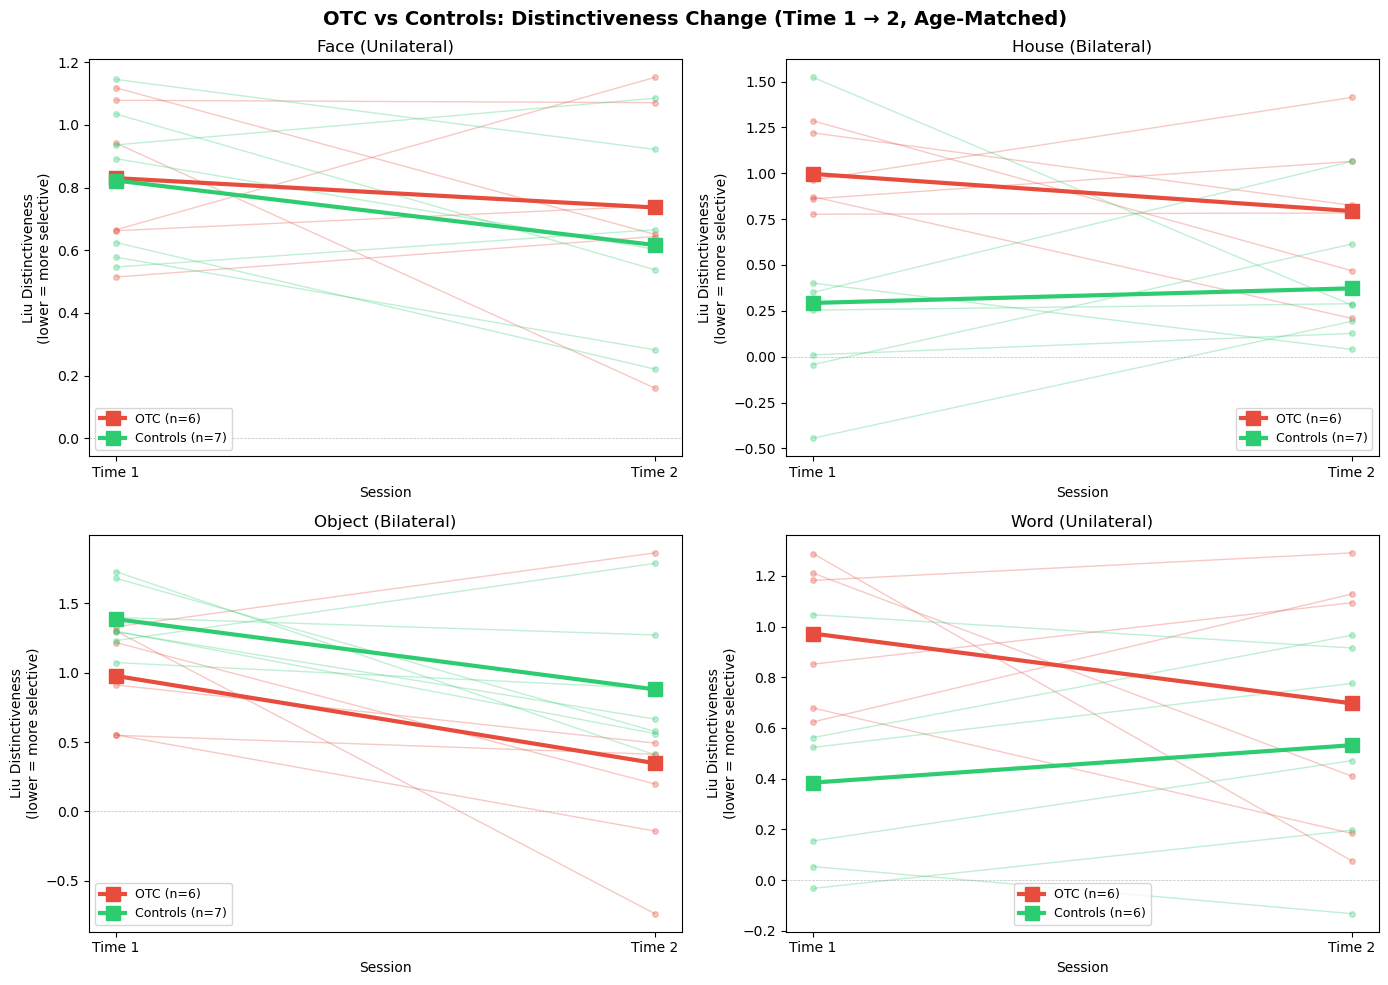

In [18]:
import matplotlib.pyplot as plt

AGE_MATCH_DROP = ['sub-025', 'sub-027', 'sub-045', 'sub-072']
categories = ['face', 'house', 'object', 'word']
groups = ['OTC', 'Controls']
colors = {'OTC': '#e74c3c', 'Controls': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for cat_idx, category in enumerate(categories):
    ax = axes[cat_idx // 2][cat_idx % 2]
    cat_type = 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral'
    
    for group_name, group_filter in [('OTC', 'OTC'), ('Controls', 'control')]:
        for subject_id in ANALYSIS_SUBJECTS.keys():
            if subject_id in AGE_MATCH_DROP:
                continue
            info = ANALYSIS_SUBJECTS[subject_id]
            if info['code'] in SUBJECTS_TO_SKIP:
                continue
            if group_filter == 'OTC' and info['group'] != 'OTC':
                continue
            if group_filter == 'control' and info['patient_status'] != 'control':
                continue
            if subject_id not in liu_distinctiveness:
                continue
            if category not in liu_distinctiveness[subject_id]:
                continue
            
            sessions_data = liu_distinctiveness[subject_id][category]
            session_keys = sorted(sessions_data.keys())
            if len(session_keys) < 2:
                continue
            
            # Only first two sessions
            s1, s2 = session_keys[0], session_keys[1]
            y_vals = [sessions_data[s1]['liu_distinctiveness'], 
                      sessions_data[s2]['liu_distinctiveness']]
            
            ax.plot([0, 1], y_vals, '-o', color=colors[group_name], alpha=0.3,
                    markersize=4, linewidth=1)
    
    # Group means (sessions 1 and 2 only)
    for group_name, group_filter in [('OTC', 'OTC'), ('Controls', 'control')]:
        t1_vals = []
        t2_vals = []
        for subject_id in ANALYSIS_SUBJECTS.keys():
            if subject_id in AGE_MATCH_DROP:
                continue
            info = ANALYSIS_SUBJECTS[subject_id]
            if info['code'] in SUBJECTS_TO_SKIP:
                continue
            if group_filter == 'OTC' and info['group'] != 'OTC':
                continue
            if group_filter == 'control' and info['patient_status'] != 'control':
                continue
            if subject_id not in liu_distinctiveness:
                continue
            if category not in liu_distinctiveness[subject_id]:
                continue
            sessions_data = liu_distinctiveness[subject_id][category]
            session_keys = sorted(sessions_data.keys())
            if len(session_keys) < 2:
                continue
            t1_vals.append(sessions_data[session_keys[0]]['liu_distinctiveness'])
            t2_vals.append(sessions_data[session_keys[1]]['liu_distinctiveness'])
        
        if t1_vals:
            ax.plot([0, 1], [np.mean(t1_vals), np.mean(t2_vals)], '-s',
                    color=colors[group_name], linewidth=3, markersize=10,
                    label=f'{group_name} (n={len(t1_vals)})', zorder=10)
    
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(f'{category.title()} ({cat_type})')
    ax.set_xlabel('Session')
    ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Time 1', 'Time 2'])
    ax.legend(fontsize=9)

plt.suptitle('OTC vs Controls: Distinctiveness Change (Time 1 → 2, Age-Matched)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'otc_vs_controls_t1t2.png'), dpi=150, bbox_inches='tight')
plt.show()

In [21]:
from scipy.stats import f_oneway, kruskal

# Get subject-level demographics for all three groups (age-matched)
AGE_MATCH_DROP = ['sub-025', 'sub-027', 'sub-045', 'sub-072']

demo_rows = []
for subject_id in ANALYSIS_SUBJECTS.keys():
    if subject_id in AGE_MATCH_DROP:
        continue
    info = ANALYSIS_SUBJECTS[subject_id]
    if info['code'] in SUBJECTS_TO_SKIP:
        continue
    
    sub_clean = subject_id.replace('sub-', '')
    sub_rows = df[df['sub_clean'] == sub_clean]
    if sub_rows.empty:
        continue
    
    sessions_list = info['sessions']
    if len(sessions_list) < 2:
        continue
    
    s1, s2 = sessions_list[0], sessions_list[1]
    age_rows = sub_rows[sub_rows['ses_num'].isin([int(s1), int(s2)])].sort_values('ses_num')
    if len(age_rows) < 2:
        continue
    
    age1 = age_rows.iloc[0]['age']
    age2 = age_rows.iloc[1]['age']
    gap = age2 - age1
    sex = age_rows.iloc[0]['sex']
    
    demo_rows.append({
        'Subject': info['code'],
        'Group': info['group'] if info['patient_status'] == 'patient' else 'control',
        'Age_T1': age1,
        'Age_T2': age2,
        'Gap': gap,
        'Sex': sex
    })

demo_df = pd.DataFrame(demo_rows)

print("DEMOGRAPHICS TABLE")
print("=" * 70)
print(f"{'Group':<10} {'N':<5} {'Age Mean':<10} {'Age SD':<10} {'Age Range':<16} {'Gap Mean':<10} {'Gap SD':<10}")
print("-" * 70)

group_ages = {}
group_gaps = {}

for group in ['OTC', 'nonOTC', 'control']:
    gd = demo_df[demo_df['Group'] == group]
    if len(gd) == 0:
        continue
    group_ages[group] = gd['Age_T1'].values
    group_gaps[group] = gd['Gap'].values
    
    print(f"{group:<10} {len(gd):<5} {gd['Age_T1'].mean():<10.1f} {gd['Age_T1'].std():<10.1f} "
          f"{gd['Age_T1'].min():.1f}-{gd['Age_T1'].max():.1f}{'':>4} "
          f"{gd['Gap'].mean():<10.2f} {gd['Gap'].std():<10.2f}")
    
    # Sex breakdown
    sex_counts = gd['Sex'].value_counts()
    print(f"{'':>10} Sex: {', '.join(f'{s}={n}' for s, n in sex_counts.items())}")

# Three-group tests
print("\nTHREE-GROUP COMPARISONS")
print("-" * 50)

if len(group_ages) == 3:
    f_age, p_age = f_oneway(group_ages['OTC'], group_ages['nonOTC'], group_ages['control'])
    f_gap, p_gap = f_oneway(group_gaps['OTC'], group_gaps['nonOTC'], group_gaps['control'])
    print(f"Age (ANOVA):  F={f_age:.2f}, p={p_age:.3f}")
    print(f"Gap (ANOVA):  F={f_gap:.2f}, p={p_gap:.3f}")
    
    # Also non-parametric
    h_age, p_age_k = kruskal(group_ages['OTC'], group_ages['nonOTC'], group_ages['control'])
    h_gap, p_gap_k = kruskal(group_gaps['OTC'], group_gaps['nonOTC'], group_gaps['control'])
    print(f"Age (Kruskal): H={h_age:.2f}, p={p_age_k:.3f}")
    print(f"Gap (Kruskal): H={h_gap:.2f}, p={p_gap_k:.3f}")

# Pairwise
print("\nPAIRWISE COMPARISONS")
print("-" * 50)
from itertools import combinations
for g1, g2 in combinations(group_ages.keys(), 2):
    t_age, p_age = ttest_ind(group_ages[g1], group_ages[g2])
    t_gap, p_gap = ttest_ind(group_gaps[g1], group_gaps[g2])
    print(f"{g1} vs {g2}:")
    print(f"  Age: t={t_age:.2f}, p={p_age:.3f}")
    print(f"  Gap: t={t_gap:.2f}, p={p_gap:.3f}")

DEMOGRAPHICS TABLE
Group      N     Age Mean   Age SD     Age Range        Gap Mean   Gap SD    
----------------------------------------------------------------------
OTC        6     13.5       3.1        7.8-16.6     1.16       1.03      
           Sex: Male=4, Female=2
nonOTC     7     14.2       1.8        10.3-15.7     0.97       0.88      
           Sex: Female=5, Male=2
control    7     12.7       1.6        10.2-14.9     1.63       1.04      
           Sex: Female=4, Male=3

THREE-GROUP COMPARISONS
--------------------------------------------------
Age (ANOVA):  F=0.79, p=0.471
Gap (ANOVA):  F=0.83, p=0.455
Age (Kruskal): H=2.93, p=0.231
Gap (Kruskal): H=2.84, p=0.242

PAIRWISE COMPARISONS
--------------------------------------------------
OTC vs nonOTC:
  Age: t=-0.47, p=0.650
  Gap: t=0.36, p=0.727
OTC vs control:
  Age: t=0.63, p=0.545
  Gap: t=-0.81, p=0.433
nonOTC vs control:
  Age: t=1.62, p=0.132
  Gap: t=-1.28, p=0.225


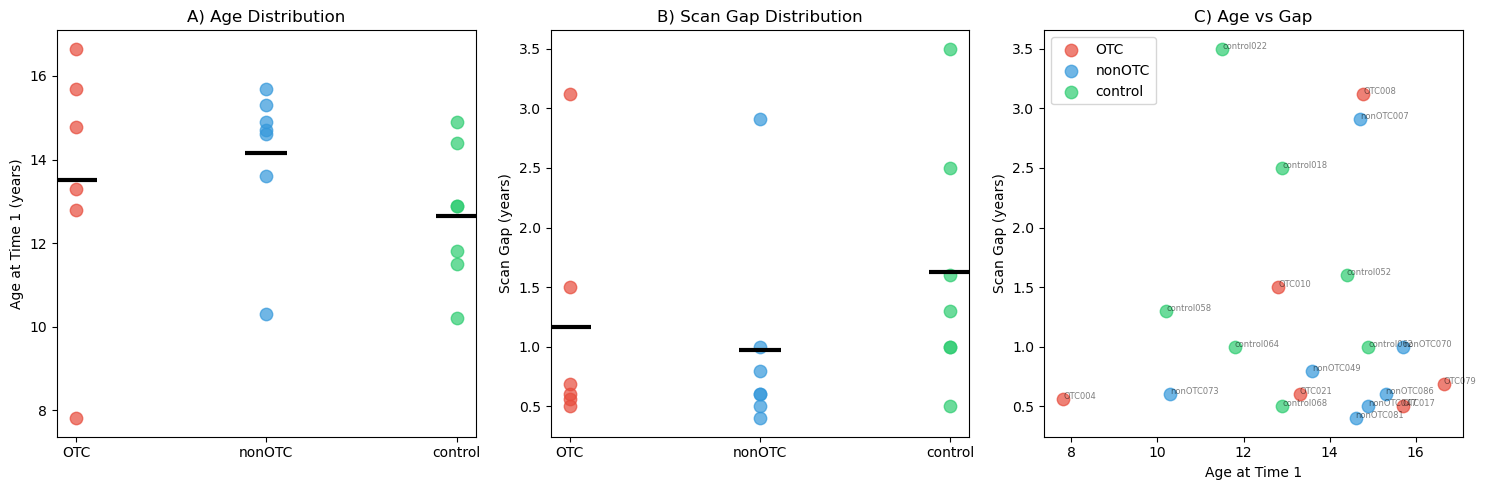


INDIVIDUAL SUBJECT DETAILS
Subject         Group      Age T1     Gap        Sex
------------------------------------------------------------
OTC004          OTC        7.8        0.56       Male
OTC010          OTC        12.8       1.50       Male
OTC021          OTC        13.3       0.60       Female
OTC008          OTC        14.8       3.12       Female
OTC017          OTC        15.7       0.50       Male
OTC079          OTC        16.6       0.69       Male
control058      control    10.2       1.30       Female
control022      control    11.5       3.50       Male
control064      control    11.8       1.00       Female
control018      control    12.9       2.50       Male
control068      control    12.9       0.50       Female
control052      control    14.4       1.60       Male
control062      control    14.9       1.00       Female
nonOTC073       nonOTC     10.3       0.60       Female
nonOTC049       nonOTC     13.6       0.80       Female
nonOTC081       nonOTC     14.6 

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'OTC': '#e74c3c', 'nonOTC': '#3498db', 'control': '#2ecc71'}

# Panel A: Age distribution
ax = axes[0]
for group in ['OTC', 'nonOTC', 'control']:
    gd = demo_df[demo_df['Group'] == group]
    ax.scatter([group] * len(gd), gd['Age_T1'], color=colors[group], s=80, alpha=0.7)
    ax.hlines(gd['Age_T1'].mean(), xmin=group, xmax=group, color=colors[group], 
              linewidth=0, alpha=0)
    ax.plot([group], [gd['Age_T1'].mean()], '_', color='black', markersize=30, markeredgewidth=3)
ax.set_ylabel('Age at Time 1 (years)')
ax.set_title('A) Age Distribution')

# Panel B: Gap distribution
ax = axes[1]
for group in ['OTC', 'nonOTC', 'control']:
    gd = demo_df[demo_df['Group'] == group]
    ax.scatter([group] * len(gd), gd['Gap'], color=colors[group], s=80, alpha=0.7)
    ax.plot([group], [gd['Gap'].mean()], '_', color='black', markersize=30, markeredgewidth=3)
ax.set_ylabel('Scan Gap (years)')
ax.set_title('B) Scan Gap Distribution')

# Panel C: Age vs Gap colored by group
ax = axes[2]
for group in ['OTC', 'nonOTC', 'control']:
    gd = demo_df[demo_df['Group'] == group]
    ax.scatter(gd['Age_T1'], gd['Gap'], color=colors[group], s=80, alpha=0.7, label=group)
    for _, row in gd.iterrows():
        ax.annotate(row['Subject'], (row['Age_T1'], row['Gap']), fontsize=6, alpha=0.5)
ax.set_xlabel('Age at Time 1')
ax.set_ylabel('Scan Gap (years)')
ax.set_title('C) Age vs Gap')
ax.legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'demographics_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print individual subject details so you can identify outliers
print("\nINDIVIDUAL SUBJECT DETAILS")
print("=" * 60)
print(f"{'Subject':<15} {'Group':<10} {'Age T1':<10} {'Gap':<10} {'Sex'}")
print("-" * 60)
for _, row in demo_df.sort_values(['Group', 'Age_T1']).iterrows():
    print(f"{row['Subject']:<15} {row['Group']:<10} {row['Age_T1']:<10.1f} {row['Gap']:<10.2f} {row['Sex']}")

In [ ]:
# ============================================================================
# CELL 7 (NEW): Cross-sectional analysis
# ============================================================================

def analyze_cross_sectional(liu_distinctiveness, analysis_subjects,
                           controls_left_distinctiveness=None):
    """
    Cross-sectional analysis: compare baseline distinctiveness across groups.
    Uses first POST-SURGICAL session for patients, first session for controls.
    Includes all three groups: OTC, nonOTC, Controls.
    """
    print('CROSS-SECTIONAL ANALYSIS')
    print('=' * 70)
    print(f'RSA Method: {RSA_METHOD}')
    print(f'Using first post-surgical session for patients')
    print(f'Hemisphere selection: {PREFERRED_HEMI}')

    rows = []

    for subject_id, info in analysis_subjects.items():
        code = info['code']
        if code in SUBJECTS_TO_SKIP:
            continue

        group = info['group'] if info['patient_status'] == 'patient' else 'control'

        # Get the first valid (post-surgery) session
        post_sessions = get_post_surgery_sessions(subject_id, info['sessions'])
        if not post_sessions:
            continue
        target_session = post_sessions[0]

        # For patients: use intact hemisphere
        if info['patient_status'] == 'patient':
            if subject_id not in liu_distinctiveness:
                continue
            for category in ['face', 'house', 'object', 'word']:
                if category not in liu_distinctiveness[subject_id]:
                    continue
                if target_session not in liu_distinctiveness[subject_id][category]:
                    continue
                distinct_val = liu_distinctiveness[subject_id][category][target_session]['liu_distinctiveness']
                cat_type = 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral'
                rows.append({
                    'Subject': code,
                    'Group': group,
                    'Category': category.title(),
                    'Category_Type': cat_type,
                    'Hemisphere': info['hemi'],
                    'Distinctiveness': distinct_val,
                    'Session': target_session
                })

        # For controls: both hemispheres
        elif info['patient_status'] == 'control':
            for hemi_label, distinct_source in [
                ('r', liu_distinctiveness.get(subject_id, {})),
                ('l', controls_left_distinctiveness.get(subject_id, {}) if controls_left_distinctiveness else {})
            ]:
                for category in ['face', 'house', 'object', 'word']:
                    if category not in distinct_source:
                        continue
                    if target_session not in distinct_source[category]:
                        continue
                    distinct_val = distinct_source[category][target_session]['liu_distinctiveness']
                    cat_type = 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral'
                    rows.append({
                        'Subject': code,
                        'Group': group,
                        'Category': category.title(),
                        'Category_Type': cat_type,
                        'Hemisphere': hemi_label,
                        'Distinctiveness': distinct_val,
                        'Session': target_session
                    })

    cross_df = pd.DataFrame(rows)

    if len(cross_df) == 0:
        print("No cross-sectional data available.")
        return pd.DataFrame()

    # Apply preferred hemisphere for controls
    ctrl_data = cross_df[cross_df['Group'] == 'control'].copy()
    preferred_ctrl = []
    for _, row in ctrl_data.iterrows():
        pref = PREFERRED_HEMI[row['Category']]
        if pref == 'both' or row['Hemisphere'] == pref:
            preferred_ctrl.append(row)
    ctrl_preferred = pd.DataFrame(preferred_ctrl)

    # Average bilateral hemispheres for controls
    if len(ctrl_preferred) > 0:
        ctrl_preferred['Subject_Base'] = ctrl_preferred['Subject']
        ctrl_avg = ctrl_preferred.groupby(['Subject_Base', 'Category', 'Category_Type', 'Group']).agg({
            'Distinctiveness': 'mean'
        }).reset_index()
    else:
        ctrl_avg = pd.DataFrame()

    # Patient data (no hemisphere averaging needed)
    patient_data = cross_df[cross_df['Group'] != 'control']

    # Counts
    n_otc = len(patient_data[patient_data['Group'] == 'OTC']['Subject'].unique())
    n_nonotc = len(patient_data[patient_data['Group'] == 'nonOTC']['Subject'].unique())
    n_ctrl = len(ctrl_avg['Subject_Base'].unique()) if len(ctrl_avg) > 0 else 0
    print(f"\nSubjects: OTC={n_otc}, nonOTC={n_nonotc}, Controls={n_ctrl}")

    # Group means
    print(f"\nBASELINE DISTINCTIVENESS (lower = more selective):")
    print(f"{'Group':<12} {'N':<5} {'Bilateral':<14} {'Unilateral':<14} {'Difference':<12}")
    print('-' * 58)

    for group_name in ['OTC', 'nonOTC', 'control']:
        if group_name == 'control':
            data = ctrl_avg
        else:
            data = patient_data[patient_data['Group'] == group_name]

        if len(data) == 0:
            print(f'{group_name:<12} no data')
            continue

        bil = data[data['Category_Type'] == 'Bilateral']['Distinctiveness']
        uni = data[data['Category_Type'] == 'Unilateral']['Distinctiveness']

        if len(bil) == 0 and len(uni) == 0:
            print(f'{group_name:<12} no data')
            continue

        n_subj = data['Subject_Base'].nunique() if 'Subject_Base' in data.columns else data['Subject'].nunique()
        bil_mean = bil.mean() if len(bil) > 0 else float('nan')
        uni_mean = uni.mean() if len(uni) > 0 else float('nan')
        print(f'{group_name:<12} {n_subj:<5} {bil_mean:<14.3f} {uni_mean:<14.3f} {bil_mean - uni_mean:<12.3f}')

    # Per-category
    print(f"\nPER-CATEGORY BASELINE DISTINCTIVENESS:")
    print(f"{'Group':<12} {'Category':<10} {'N':<5} {'Mean':<10} {'SD':<10}")
    print('-' * 50)

    for group_name in ['OTC', 'nonOTC', 'control']:
        if group_name == 'control':
            data = ctrl_avg
        else:
            data = patient_data[patient_data['Group'] == group_name]

        if len(data) == 0:
            continue

        for cat in ['Face', 'House', 'Object', 'Word']:
            cat_data = data[data['Category'] == cat]['Distinctiveness']
            if len(cat_data) == 0:
                continue
            print(f'{group_name:<12} {cat:<10} {len(cat_data):<5} {cat_data.mean():<10.3f} {cat_data.std():<10.3f}')

    # Statistical tests (OTC vs Controls, nonOTC vs Controls)
    print(f"\nSTATISTICAL COMPARISONS:")
    print('-' * 50)
    from scipy.stats import mannwhitneyu, ttest_ind

    for cat_type in ['Bilateral', 'Unilateral']:
        print(f"\n{cat_type}:")
        ctrl_vals = ctrl_avg[ctrl_avg['Category_Type'] == cat_type]['Distinctiveness'].values if len(ctrl_avg) > 0 else np.array([])

        for group_name in ['OTC', 'nonOTC']:
            grp_vals = patient_data[(patient_data['Group'] == group_name) &
                                   (patient_data['Category_Type'] == cat_type)]['Distinctiveness'].values
            if len(grp_vals) > 2 and len(ctrl_vals) > 2:
                t, p_t = ttest_ind(grp_vals, ctrl_vals)
                u, p_u = mannwhitneyu(grp_vals, ctrl_vals, alternative='two-sided')
                print(f"  {group_name} vs Controls: t={t:.2f} p={p_t:.3f}, U={u:.0f} p={p_u:.3f}")
                print(f"    {group_name} mean={grp_vals.mean():.3f}, Controls mean={ctrl_vals.mean():.3f}")

    return cross_df, ctrl_avg, patient_data


# Run cross-sectional
print('\n' + '=' * 50)
cross_df, ctrl_cross, patient_cross = analyze_cross_sectional(
    liu_distinctiveness, ANALYSIS_SUBJECTS, controls_left_distinctiveness
)
print('\nCross-sectional analysis complete!')

In [14]:
# CELL 7: Verification

print('=' * 70)
print('VERIFICATION')
print('=' * 70)

print(f'\n1. BASIC COUNTS:')
print(f'   Total rows: {len(results_table)}')
if len(results_table) > 0:
    print(f'   Unique subjects: {results_table["Subject"].nunique()}')

print(f'\n2. CONTROL HEMISPHERES:')
if len(results_table) > 0:
    controls = results_table[results_table['Status'] == 'control']
    has_L = any('_L' in str(s) for s in controls['Subject'].unique())
    has_R = any('_R' in str(s) for s in controls['Subject'].unique())
    print(f'   Has _L: {has_L}, Has _R: {has_R}')

print(f'\n3. GROUP COUNTS:')
if len(results_table) > 0:
    for group in ['OTC', 'nonOTC']:
        n = len(results_table[results_table['Group'] == group])
        print(f'   {group}: {n} rows')
    n_ctrl = len(results_table[results_table['Status'] == 'control'])
    print(f'   Controls: {n_ctrl} rows')

print(f'\n4. PARAMETERS:')
print(f'   COPE_MAP: {COPE_MAP}')
print(f'   Sphere: 6mm, z>2.3, min 50 voxels')

VERIFICATION

1. BASIC COUNTS:
   Total rows: 125
   Unique subjects: 33

2. CONTROL HEMISPHERES:
   Has _L: True, Has _R: True

3. GROUP COUNTS:
   OTC: 24 rows
   nonOTC: 33 rows
   Controls: 68 rows

4. PARAMETERS:
   COPE_MAP: {'face': 1, 'house': 2, 'object': 3, 'word': 12}
   Sphere: 6mm, z>2.3, min 50 voxels


In [ ]:
# ============================================================================
# CELL 8 (NEW): Cross-sectional visualization
# ============================================================================

import matplotlib.pyplot as plt

def plot_cross_sectional(patient_data, ctrl_avg):
    """Plot cross-sectional group differences."""

    categories = ['Face', 'House', 'Object', 'Word']
    groups = ['OTC', 'nonOTC', 'control']
    colors = {'OTC': '#e74c3c', 'nonOTC': '#3498db', 'control': '#2ecc71'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel A: By category
    ax = axes[0]
    x = np.arange(len(categories))
    width = 0.25

    for i, group in enumerate(groups):
        if group == 'control':
            data = ctrl_avg
        else:
            data = patient_data[patient_data['Group'] == group]

        means = []
        sems = []
        for cat in categories:
            cat_vals = data[data['Category'] == cat]['Distinctiveness']
            means.append(cat_vals.mean() if len(cat_vals) > 0 else 0)
            sems.append(cat_vals.std() / np.sqrt(len(cat_vals)) if len(cat_vals) > 1 else 0)

        ax.bar(x + i * width, means, width, yerr=sems, label=group, color=colors[group],
               alpha=0.8, capsize=3)

    ax.set_ylabel('Distinctiveness\n(lower = more selective)')
    ax.set_xticks(x + width)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.set_title('A) Baseline Distinctiveness by Category')

    # Panel B: Individual subjects by bilateral vs unilateral
    ax = axes[1]

    for i, group in enumerate(groups):
        if group == 'control':
            data = ctrl_avg
            subj_col = 'Subject_Base'
        else:
            data = patient_data[patient_data['Group'] == group]
            subj_col = 'Subject'

        if len(data) == 0:
            continue

        for subj in data[subj_col].unique():
            subj_data = data[data[subj_col] == subj]
            bil = subj_data[subj_data['Category_Type'] == 'Bilateral']['Distinctiveness'].mean()
            uni = subj_data[subj_data['Category_Type'] == 'Unilateral']['Distinctiveness'].mean()
            ax.scatter(i, bil, color=colors[group], marker='o', alpha=0.5, s=40)
            ax.scatter(i + 0.3, uni, color=colors[group], marker='^', alpha=0.5, s=40)

        # Group means
        bil_mean = data[data['Category_Type'] == 'Bilateral']['Distinctiveness'].mean()
        uni_mean = data[data['Category_Type'] == 'Unilateral']['Distinctiveness'].mean()
        ax.plot([i], [bil_mean], 'o', color=colors[group], markersize=12, zorder=10)
        ax.plot([i + 0.3], [uni_mean], '^', color=colors[group], markersize=12, zorder=10)

    ax.set_xticks([0.15, 1.15, 2.15])
    ax.set_xticklabels(groups)
    ax.set_ylabel('Distinctiveness\n(lower = more selective)')
    ax.set_title('B) Bilateral (o) vs Unilateral (^)')
    ax.legend(['Bilateral', 'Unilateral'], loc='upper right')

    plt.suptitle(f'Cross-Sectional Group Comparison (RSA: {RSA_METHOD})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f'cross_sectional_{RSA_METHOD}.png'), dpi=150, bbox_inches='tight')
    plt.show()


if len(patient_cross) > 0:
    plot_cross_sectional(patient_cross, ctrl_cross)